<a href="https://colab.research.google.com/github/Priji123/Mtech_final_year_project/blob/main/crack_severity_analysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Crack Severity Analysis — Stage 2
**Google Colab | Attention U-Net → Severity Pipeline**

### What this notebook does
1. Downloads the `aravindnagarajan/crack-segmentation-dataset` via kagglehub  
2. Reconstructs the Attention U-Net and loads weights from `best_model.h5`  
3. Runs inference on the test split  
4. Computes severity metrics (area, width, length, level) per image  
5. Optionally evaluates predicted masks against ground-truth masks (IoU, Dice)  
6. Saves results to CSV + visualisations

---
> **Dataset folder structure** (after download):  
> ```
> <path>/
>   train/
>     images/   *.jpg
>     masks/    *.jpg
>   test/
>     images/   *.jpg
>     masks/    *.jpg
> ```
> Non-cracked images follow the naming pattern `noncrack*`.

## Cell 1 — Install Dependencies

In [ ]:
!pip install kagglehub opencv-python-headless scikit-image matplotlib scipy tqdm pandas -q

## Cell 2 — Mount Drive & Set Model Path

Upload `best_model.h5` to your Google Drive first.  
Recommended location: `MyDrive/crack_model/best_model.h5`

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ✏️ Update this path to your best_model.h5 in Drive
MODEL_H5_PATH = "/content/drive/MyDrive/Compuer_trained/best_model.h5"

if os.path.exists(MODEL_H5_PATH):
    size_mb = os.path.getsize(MODEL_H5_PATH) / (1024 * 1024)
    print(f"✅ Model found: {MODEL_H5_PATH}  ({size_mb:.1f} MB)")
else:
    print("❌ Model file NOT found — check path above.")

Mounted at /content/drive
✅ Model found: /content/drive/MyDrive/Compuer_trained/best_model.h5  (93.5 MB)


## Cell 3 — Download Dataset via kagglehub

First time: Colab will ask for your Kaggle credentials.  
Fastest way: place a `kaggle.json` in Drive and copy it to `~/.kaggle/`.

In [ ]:
# --- Option A: kaggle.json already in Drive ---
# Uncomment and adjust if you stored kaggle.json in your Drive
# import shutil
# shutil.copy("/content/drive/MyDrive/kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
# os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

import kagglehub
import os

DATASET_PATH = kagglehub.dataset_download("aravindnagarajan/crack-segmentation-dataset")
print("\nDataset downloaded to:", DATASET_PATH)

# Explore the structure
for root, dirs, files in os.walk(DATASET_PATH):
    depth = root.replace(DATASET_PATH, '').count(os.sep)
    indent = '  ' * depth
    folder = os.path.basename(root)
    n_files = len(files)
    print(f"{indent}📁 {folder}/  ({n_files} files)")
    if depth >= 2:          # don't recurse deeper than train/images
        break

Using Colab cache for faster access to the 'crack-segmentation-dataset' dataset.

Dataset downloaded to: /kaggle/input/crack-segmentation-dataset
📁 crack-segmentation-dataset/  (0 files)
  📁 test/  (0 files)
    📁 images/  (1695 files)


## Cell 4 — Resolve Dataset Paths

In [ ]:
import glob

# Handles both flat layout and nested version folders from kagglehub
def find_split(base, split="test"):
    """Return (images_dir, masks_dir) for a given split."""
    # Try direct
    candidate_imgs  = os.path.join(base, split, "images")
    candidate_masks = os.path.join(base, split, "masks")
    if os.path.isdir(candidate_imgs):
        return candidate_imgs, candidate_masks
    # kagglehub sometimes adds a version subfolder
    for sub in sorted(os.listdir(base)):
        p = os.path.join(base, sub, split, "images")
        if os.path.isdir(p):
            return p, os.path.join(base, sub, split, "masks")
    raise FileNotFoundError(f"Could not find '{split}/images' under {base}")


TEST_IMGS_DIR,  TEST_MASKS_DIR  = find_split(DATASET_PATH, "test")
TRAIN_IMGS_DIR, TRAIN_MASKS_DIR = find_split(DATASET_PATH, "train")

def count_imgs(d):
    return sum(len(glob.glob(os.path.join(d, f"*.{e}"))) for e in ("jpg", "jpeg", "png", "bmp"))

print(f"Train images : {count_imgs(TRAIN_IMGS_DIR)}  →  {TRAIN_IMGS_DIR}")
print(f"Train masks  : {count_imgs(TRAIN_MASKS_DIR)}  →  {TRAIN_MASKS_DIR}")
print(f"Test  images : {count_imgs(TEST_IMGS_DIR)}  →  {TEST_IMGS_DIR}")
print(f"Test  masks  : {count_imgs(TEST_MASKS_DIR)}  →  {TEST_MASKS_DIR}")

Train images : 9603  →  /kaggle/input/crack-segmentation-dataset/train/images
Train masks  : 9603  →  /kaggle/input/crack-segmentation-dataset/train/masks
Test  images : 1695  →  /kaggle/input/crack-segmentation-dataset/test/images
Test  masks  : 1695  →  /kaggle/input/crack-segmentation-dataset/test/masks


## Cell 5 — Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.morphology import skeletonize
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from tqdm import tqdm
import csv
import os

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 6 — Rebuild Attention U-Net Architecture

Exact same architecture as training — **no mixed precision** (inference runs in float32).

In [ ]:
IMG_SIZE = 448   # must match training


def conv_block(x, num_filters):
    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)
    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)
    return x


def encoder_block(x, num_filters):
    s = conv_block(x, num_filters)
    p = L.MaxPool2D((2, 2))(s)
    return s, p


def attention_gate(g, s, num_filters):
    Wg = L.Conv2D(num_filters, 1, padding="same")(g)
    Wg = L.BatchNormalization()(Wg)
    Ws = L.Conv2D(num_filters, 1, padding="same")(s)
    Ws = L.BatchNormalization()(Ws)
    out = L.Activation("relu")(Wg + Ws)
    out = L.Conv2D(1, 1, padding="same", activation="sigmoid")(out)
    return L.Multiply()([out, s])


def decoder_block(x, s, num_filters):
    x = L.UpSampling2D(interpolation="bilinear")(x)
    s = attention_gate(x, s, num_filters)
    x = L.Concatenate()([x, s])
    x = conv_block(x, num_filters)
    return x


def build_attention_unet(input_shape=(448, 448, 3)):
    inputs = L.Input(input_shape)
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1,    64)
    s3, p3 = encoder_block(p2,    128)
    s4, p4 = encoder_block(p3,    256)
    b1     = conv_block(p4, 512)
    d1     = decoder_block(b1, s4, 256)
    d2     = decoder_block(d1, s3, 128)
    d3     = decoder_block(d2, s2,  64)
    d4     = decoder_block(d3, s1,  32)
    outputs = L.Conv2D(1, 1, padding="same", activation="sigmoid", dtype="float32")(d4)
    return tf.keras.Model(inputs, outputs, name="Attention_U-Net")


model = build_attention_unet()
print(f"✅ Architecture built  |  Params: {model.count_params():,}")

✅ Architecture built  |  Params: 8,124,837


## Cell 7 — Load Weights

Using `load_weights` (not `load_model`) to avoid TF version / custom object issues.

In [ ]:
model.load_weights(MODEL_H5_PATH, by_name=False, skip_mismatch=False)
print("✅ Weights loaded from:", MODEL_H5_PATH)

# Sanity check
dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
out   = model.predict(dummy, verbose=0)
print(f"✅ Forward pass OK  |  output shape: {out.shape}  range: [{out.min():.4f}, {out.max():.4f}]")

NameError: name 'MODEL_H5_PATH' is not defined

## Cell 8 — Inference & Severity Functions

In [ ]:
PRED_THRESHOLD = 0.5   # lower → more sensitive; raise to reduce false positives

# ── Severity thresholds (based on crack area %) ──────────────────────────────
# Tune these to match your structural engineering standards
SEVERITY_THRESHOLDS = {
    "NONE":     0.0,
    "LOW":      0.01,   # 0.01% – 1%
    "MEDIUM":   1.0,    # 1%    – 3%
    "HIGH":     3.0,    # 3%    – 7%
    "CRITICAL": 7.0,    # > 7%
}

SEVERITY_COLOR = {
    "NONE":     (0.30, 0.80, 0.30),
    "LOW":      (0.90, 0.90, 0.20),
    "MEDIUM":   (1.00, 0.60, 0.10),
    "HIGH":     (0.90, 0.20, 0.20),
    "CRITICAL": (0.60, 0.00, 0.80),
}


def predict_mask(image_path, threshold=PRED_THRESHOLD):
    """
    Returns
    -------
    orig_rgb  : (H, W, 3) float32 [0,1]  RGB
    prob_map  : (H, W)    float32        raw model output
    bin_mask  : (H, W)    uint8          {0, 255}
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot read: {image_path}")
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    prob = model.predict(orig_rgb[np.newaxis], verbose=0)[0, :, :, 0]
    bin_mask = ((prob >= threshold) * 255).astype(np.uint8)
    return orig_rgb, prob, bin_mask


def load_gt_mask(mask_path):
    """Load a ground-truth mask as binary uint8 {0, 255}."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    return ((mask > 127) * 255).astype(np.uint8)


def compute_severity(bin_mask):
    """
    Returns a dict with severity metrics computed from a binary mask.
    """
    bool_mask    = bin_mask > 127
    total_px     = IMG_SIZE * IMG_SIZE
    crack_px     = int(np.sum(bool_mask))
    area_ratio   = (crack_px / total_px) * 100.0

    skeleton        = skeletonize(bool_mask)
    crack_length_px = int(np.sum(skeleton))

    if crack_px > 0:
        dist      = distance_transform_edt(bool_mask)
        skel_dist = dist[skeleton]
        max_width  = float(np.max(skel_dist)  * 2) if len(skel_dist) else 0.0
        mean_width = float(np.mean(skel_dist) * 2) if len(skel_dist) else 0.0
    else:
        max_width = mean_width = 0.0

    num_regions = int(label(bool_mask).max())

    # Severity classification
    if area_ratio == 0:
        level = "NONE"
    elif area_ratio < SEVERITY_THRESHOLDS["MEDIUM"]:
        level = "LOW"
    elif area_ratio < SEVERITY_THRESHOLDS["HIGH"]:
        level = "MEDIUM"
    elif area_ratio < SEVERITY_THRESHOLDS["CRITICAL"]:
        level = "HIGH"
    else:
        level = "CRITICAL"

    return {
        "crack_area_pct":     round(area_ratio,  4),
        "max_width_px":       round(max_width,   2),
        "mean_width_px":      round(mean_width,  2),
        "crack_length_px":    crack_length_px,
        "num_crack_regions":  num_regions,
        "severity_level":     level,
        "skeleton":           skeleton,
    }


def seg_metrics(pred_mask, gt_mask):
    """Compute IoU and Dice between two binary uint8 masks."""
    p = pred_mask > 127
    g = gt_mask   > 127
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    iou   = inter / (union + 1e-8)
    dice  = 2 * inter / (p.sum() + g.sum() + 1e-8)
    return round(float(iou), 4), round(float(dice), 4)


print("✅ All inference and severity functions ready.")

✅ All inference and severity functions ready.


In [ ]:
# ── Cell 8b — Grad-CAM for Attention U-Net ──────────────────────────────────

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Pick the last encoder conv layer — good balance of spatial res + semantic info
# In your architecture, the bridge conv output feeds into 's4', 'b1' etc.
# We target the bridge (bottleneck) layer for global crack cues,
# or 's4' (encoder level 4) for more spatially-detailed heatmaps.

GRADCAM_LAYER = "conv2d_8"   # ← name of the bridge/bottleneck conv layer
                               # Run model.summary() to confirm exact name

def get_gradcam_layer_name(model, encoder_depth=4):
    """Auto-detect the last encoder conv layer name."""
    conv_layers = [l.name for l in model.layers if "conv2d" in l.name and "batch" not in l.name]
    # Bridge conv layers appear around index 2*encoder_depth*2
    # Simple heuristic: pick the middle conv layer (bridge)
    return conv_layers[len(conv_layers) // 2]


def compute_gradcam(model, image_path, layer_name=None, threshold=0.5):
    """
    Compute Grad-CAM heatmap for a segmentation model.

    For segmentation, we use the mean of the predicted mask as the
    scalar loss (instead of a class score), so gradients flow from
    the mask output back through the specified conv layer.

    Parameters
    ----------
    model      : trained Keras model
    image_path : path to input image
    layer_name : name of target conv layer (None = auto-detect bridge)
    threshold  : prediction threshold for binary mask

    Returns
    -------
    orig_rgb   : (H, W, 3) float32 original image
    heatmap    : (H, W) float32 Grad-CAM heatmap [0, 1]
    pred_mask  : (H, W) uint8 binary mask
    overlay    : (H, W, 3) float32 heatmap overlaid on image
    """
    if layer_name is None:
        layer_name = get_gradcam_layer_name(model)

    # Load and preprocess image
    img_bgr = cv2.imread(image_path)
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_tensor = tf.convert_to_tensor(orig_rgb[np.newaxis], dtype=tf.float32)

    # Build a sub-model that outputs (feature_map, prediction)
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    # Record gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        # For segmentation: use mean of the predicted crack area as the scalar
        # This gives gradients w.r.t. "how much crack is predicted overall"
        loss = tf.reduce_mean(predictions)

    # Gradients of the loss w.r.t. the conv feature map
    grads = tape.gradient(loss, conv_outputs)          # (1, h, w, C)

    # Pool gradients over spatial dims → importance weight per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    # Weighted combination of feature maps
    conv_outputs = conv_outputs[0]                        # (h, w, C)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # (h, w, 1)
    heatmap = tf.squeeze(heatmap)                         # (h, w)

    # ReLU + normalize to [0, 1]
    heatmap = tf.nn.relu(heatmap).numpy()
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    # Resize heatmap to input resolution
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    # Colorize with jet colormap
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3].astype(np.float32)  # (H, W, 3)

    # Blend with original image
    overlay = 0.5 * orig_rgb + 0.5 * heatmap_colored
    overlay = np.clip(overlay, 0, 1)

    # Binary predicted mask
    pred_raw = model.predict(img_tensor, verbose=0)[0, :, :, 0]
    pred_mask = ((pred_raw >= threshold) * 255).astype(np.uint8)

    return orig_rgb, heatmap_resized, pred_mask, overlay


def visualize_gradcam(image_path, layer_name=None, threshold=PRED_THRESHOLD):
    """Full visualization: Original | GT Mask | Pred Mask | Grad-CAM | Overlay."""
    orig, heatmap, pred_mask, overlay = compute_gradcam(
        model, image_path, layer_name, threshold
    )

    fname   = os.path.basename(image_path)
    gt_path = os.path.join(TEST_MASKS_DIR, fname)
    gt_mask = load_gt_mask(gt_path) if os.path.exists(gt_path) else None

    severity = compute_severity(pred_mask)
    color    = SEVERITY_COLOR[severity["severity_level"]]

    n_cols = 5 if gt_mask is not None else 4
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    col = 0
    axes[col].imshow(orig);                   axes[col].set_title("Original");        axes[col].axis("off"); col += 1
    if gt_mask is not None:
        axes[col].imshow(gt_mask, cmap="gray"); axes[col].set_title("GT Mask");        axes[col].axis("off"); col += 1
    axes[col].imshow(pred_mask, cmap="gray"); axes[col].set_title("Pred Mask");       axes[col].axis("off"); col += 1
    axes[col].imshow(heatmap, cmap="jet");    axes[col].set_title("Grad-CAM");        axes[col].axis("off"); col += 1
    axes[col].imshow(overlay);                axes[col].set_title("Grad-CAM Overlay"); axes[col].axis("off")

    iou_str = ""
    if gt_mask is not None:
        iou, dice = seg_metrics(pred_mask, gt_mask)
        iou_str = f"  IoU: {iou:.3f}  Dice: {dice:.3f}"

    fig.suptitle(
        f"{fname}  |  Severity: {severity['severity_level']}  |  "
        f"Area: {severity['crack_area_pct']:.2f}%{iou_str}",
        fontsize=11, color=color, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

print("✅ Grad-CAM functions ready.")
print("Target layer (auto):", get_gradcam_layer_name(model))

✅ Grad-CAM functions ready.
Target layer (auto): conv2d_15


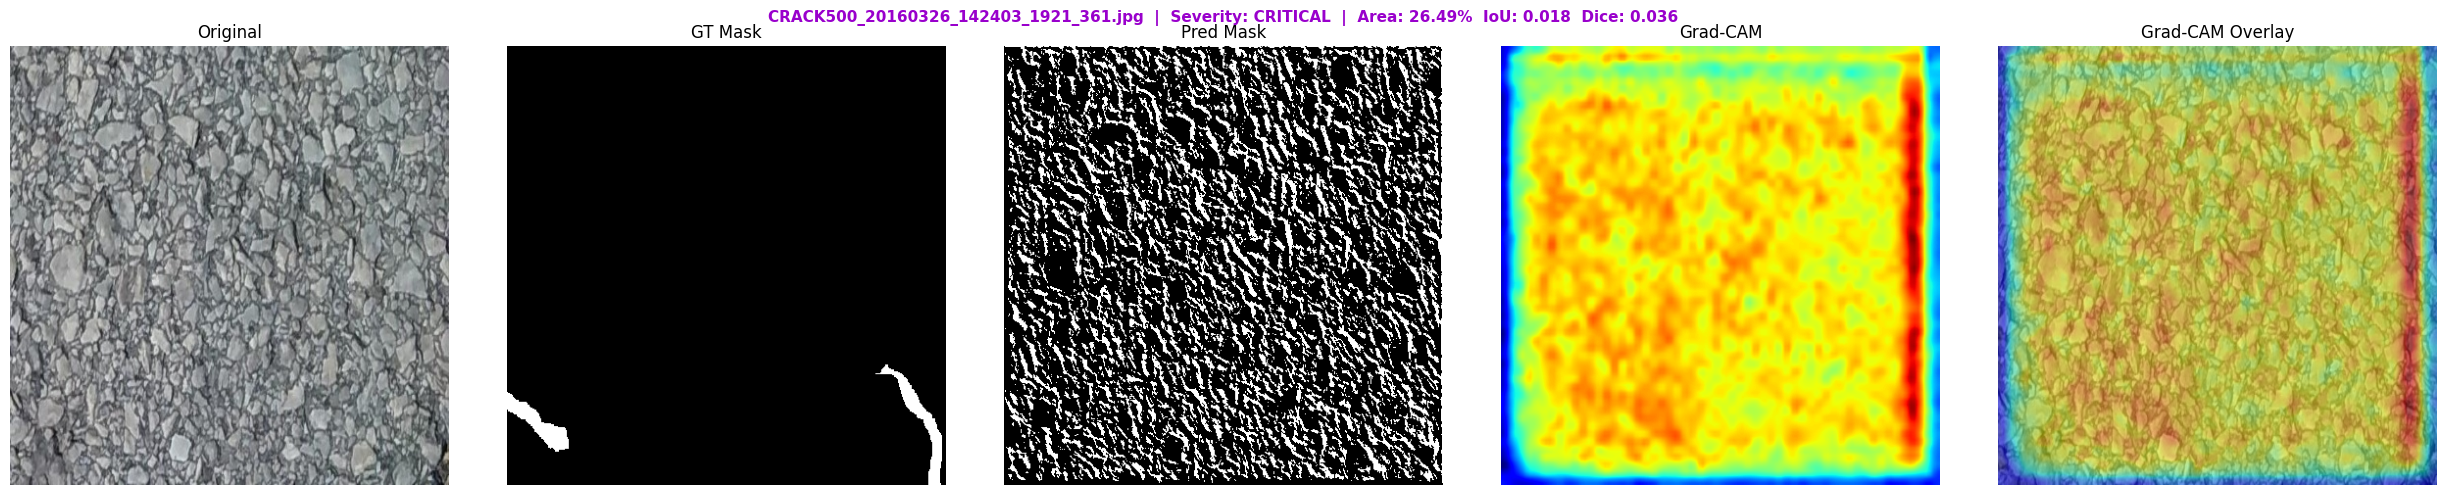

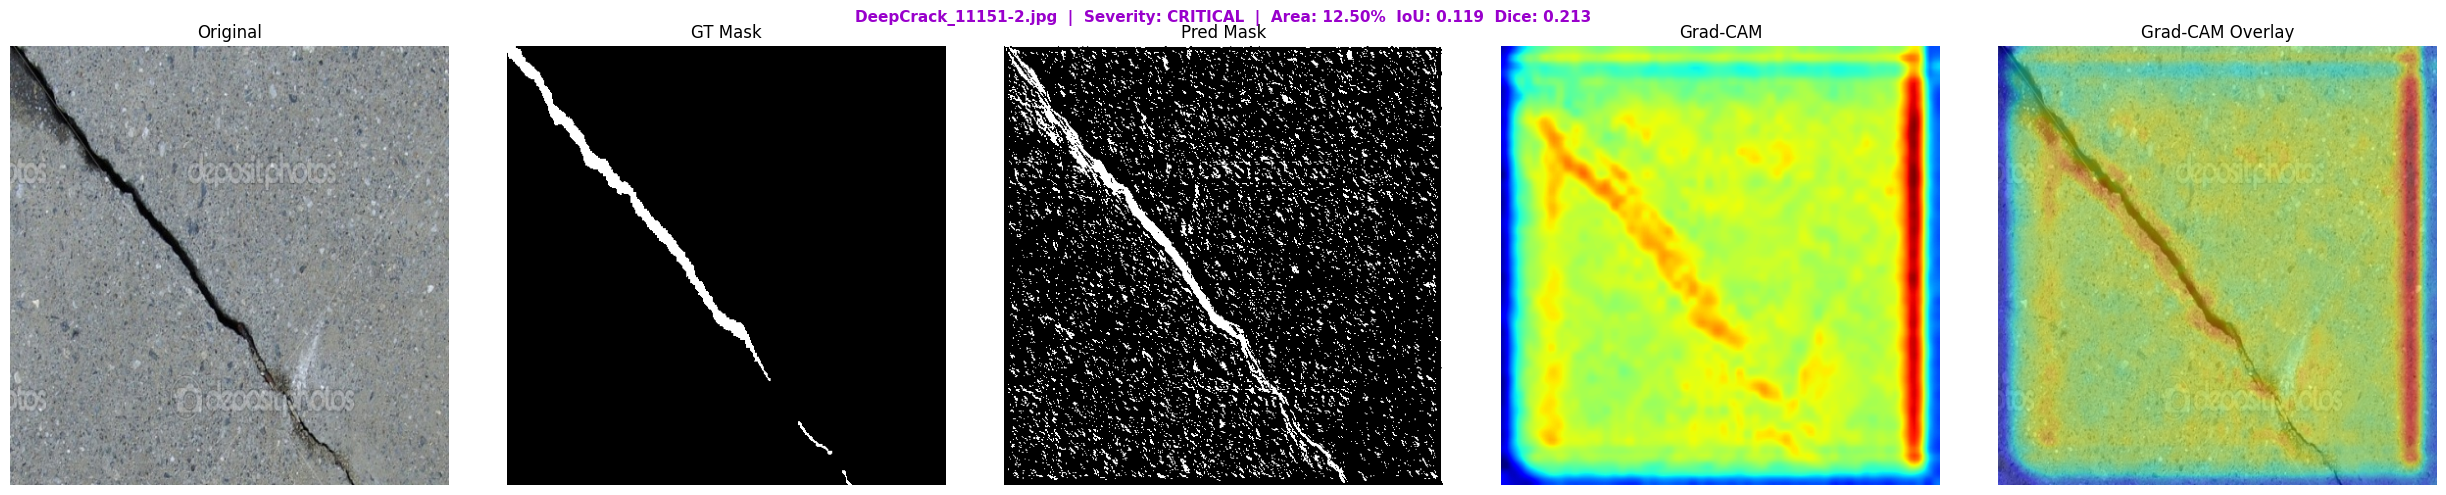

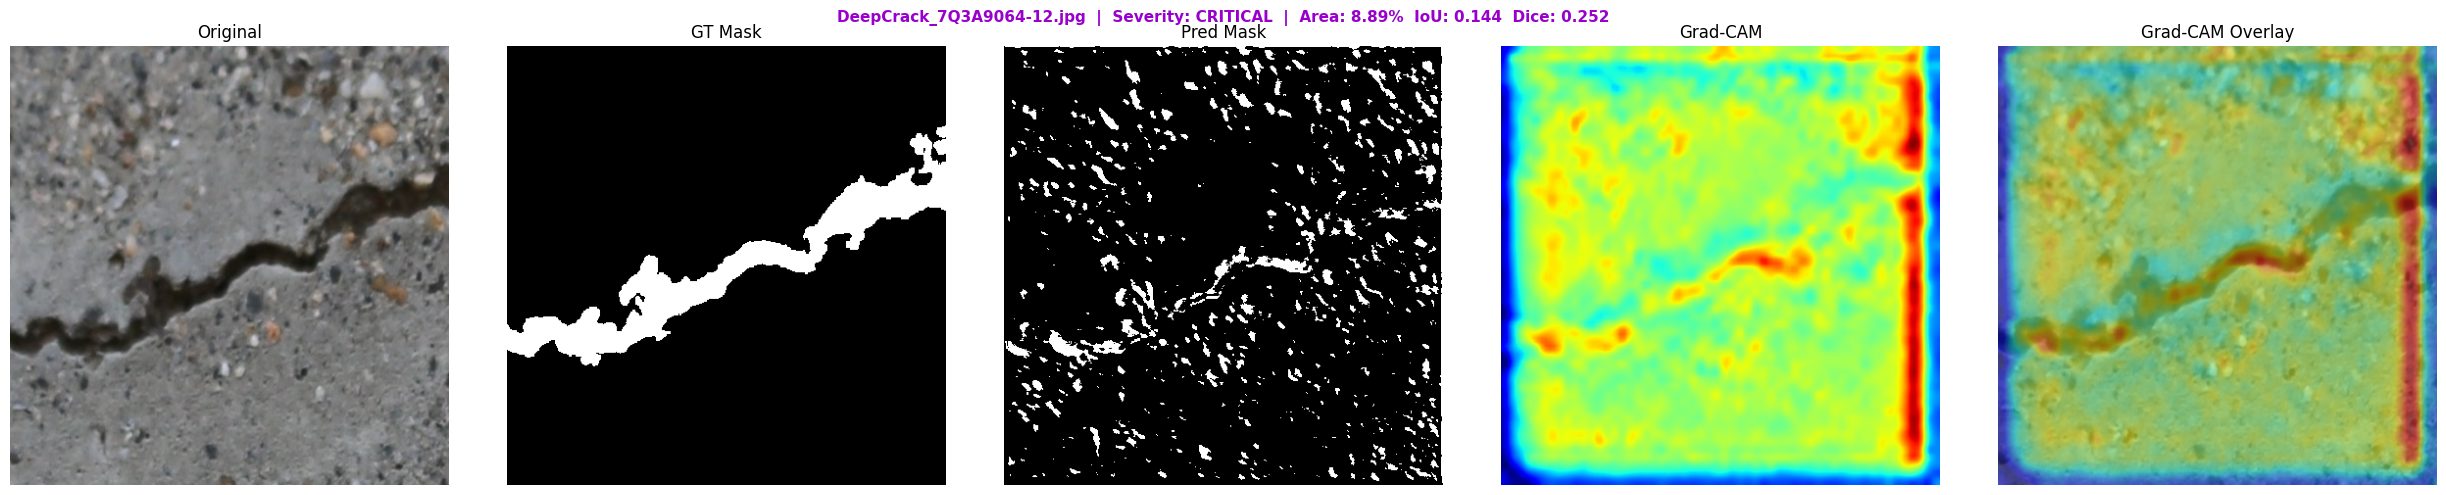

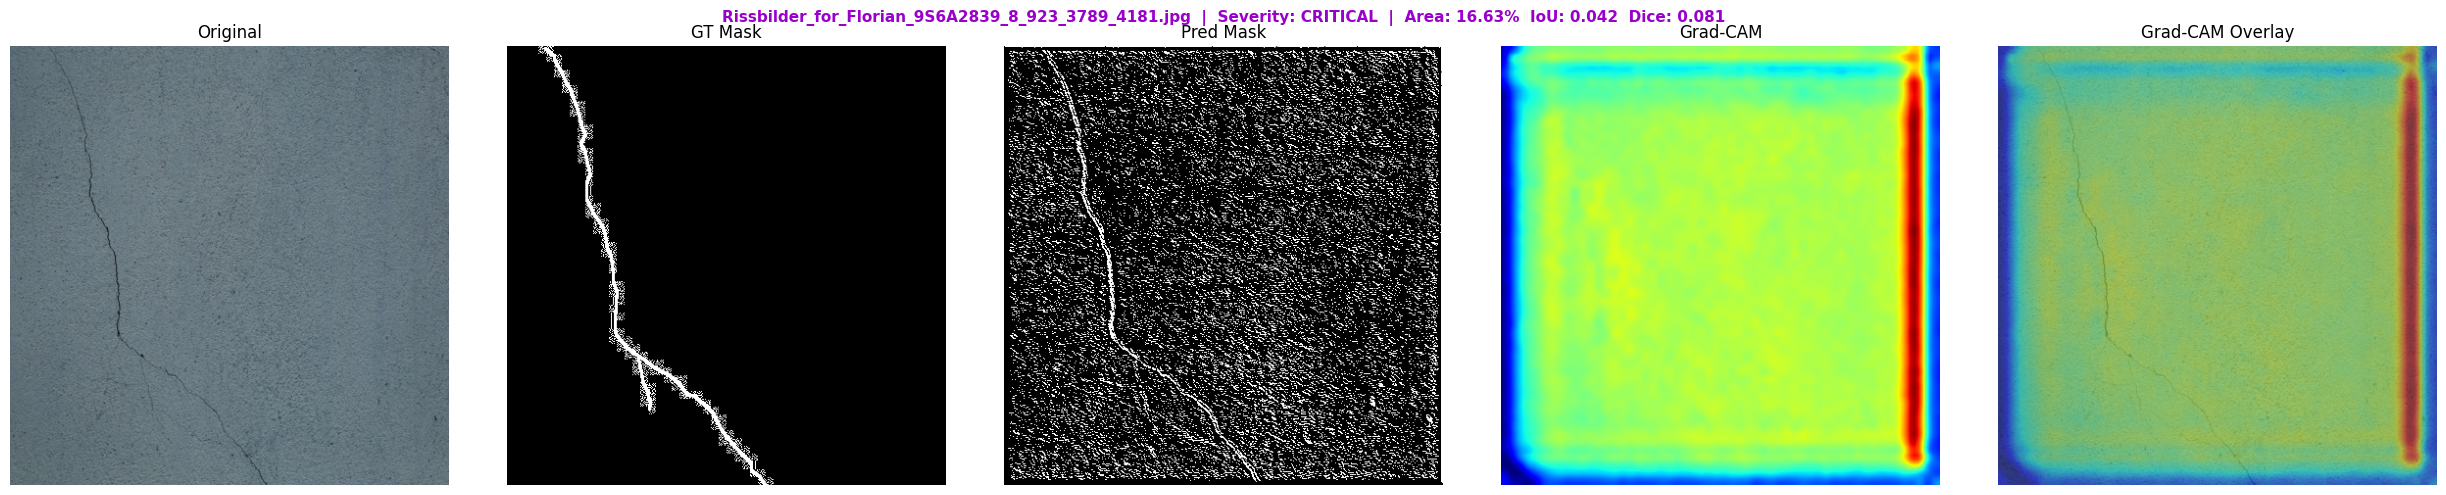

In [ ]:
# ── Cell 8c — Run Grad-CAM on samples ───────────────────────────────────────
import random
import matplotlib.cm as cm

# Define cracked list (Cell 9 hasn't run yet)
all_test_imgs = sorted(
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.jpg")) +
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.png"))
)
cracked = [p for p in all_test_imgs if "noncrack" not in os.path.basename(p).lower()]

# Auto-detect layer
layer_name = get_gradcam_layer_name(model)

sample_imgs = random.sample(cracked, min(4, len(cracked)))

for img_path in sample_imgs:
    visualize_gradcam(img_path, layer_name=layer_name)

## Cell 9 — Quick Test on 6 Random Images

Visual sanity-check before running the full batch.

Testing on 6 sample images...


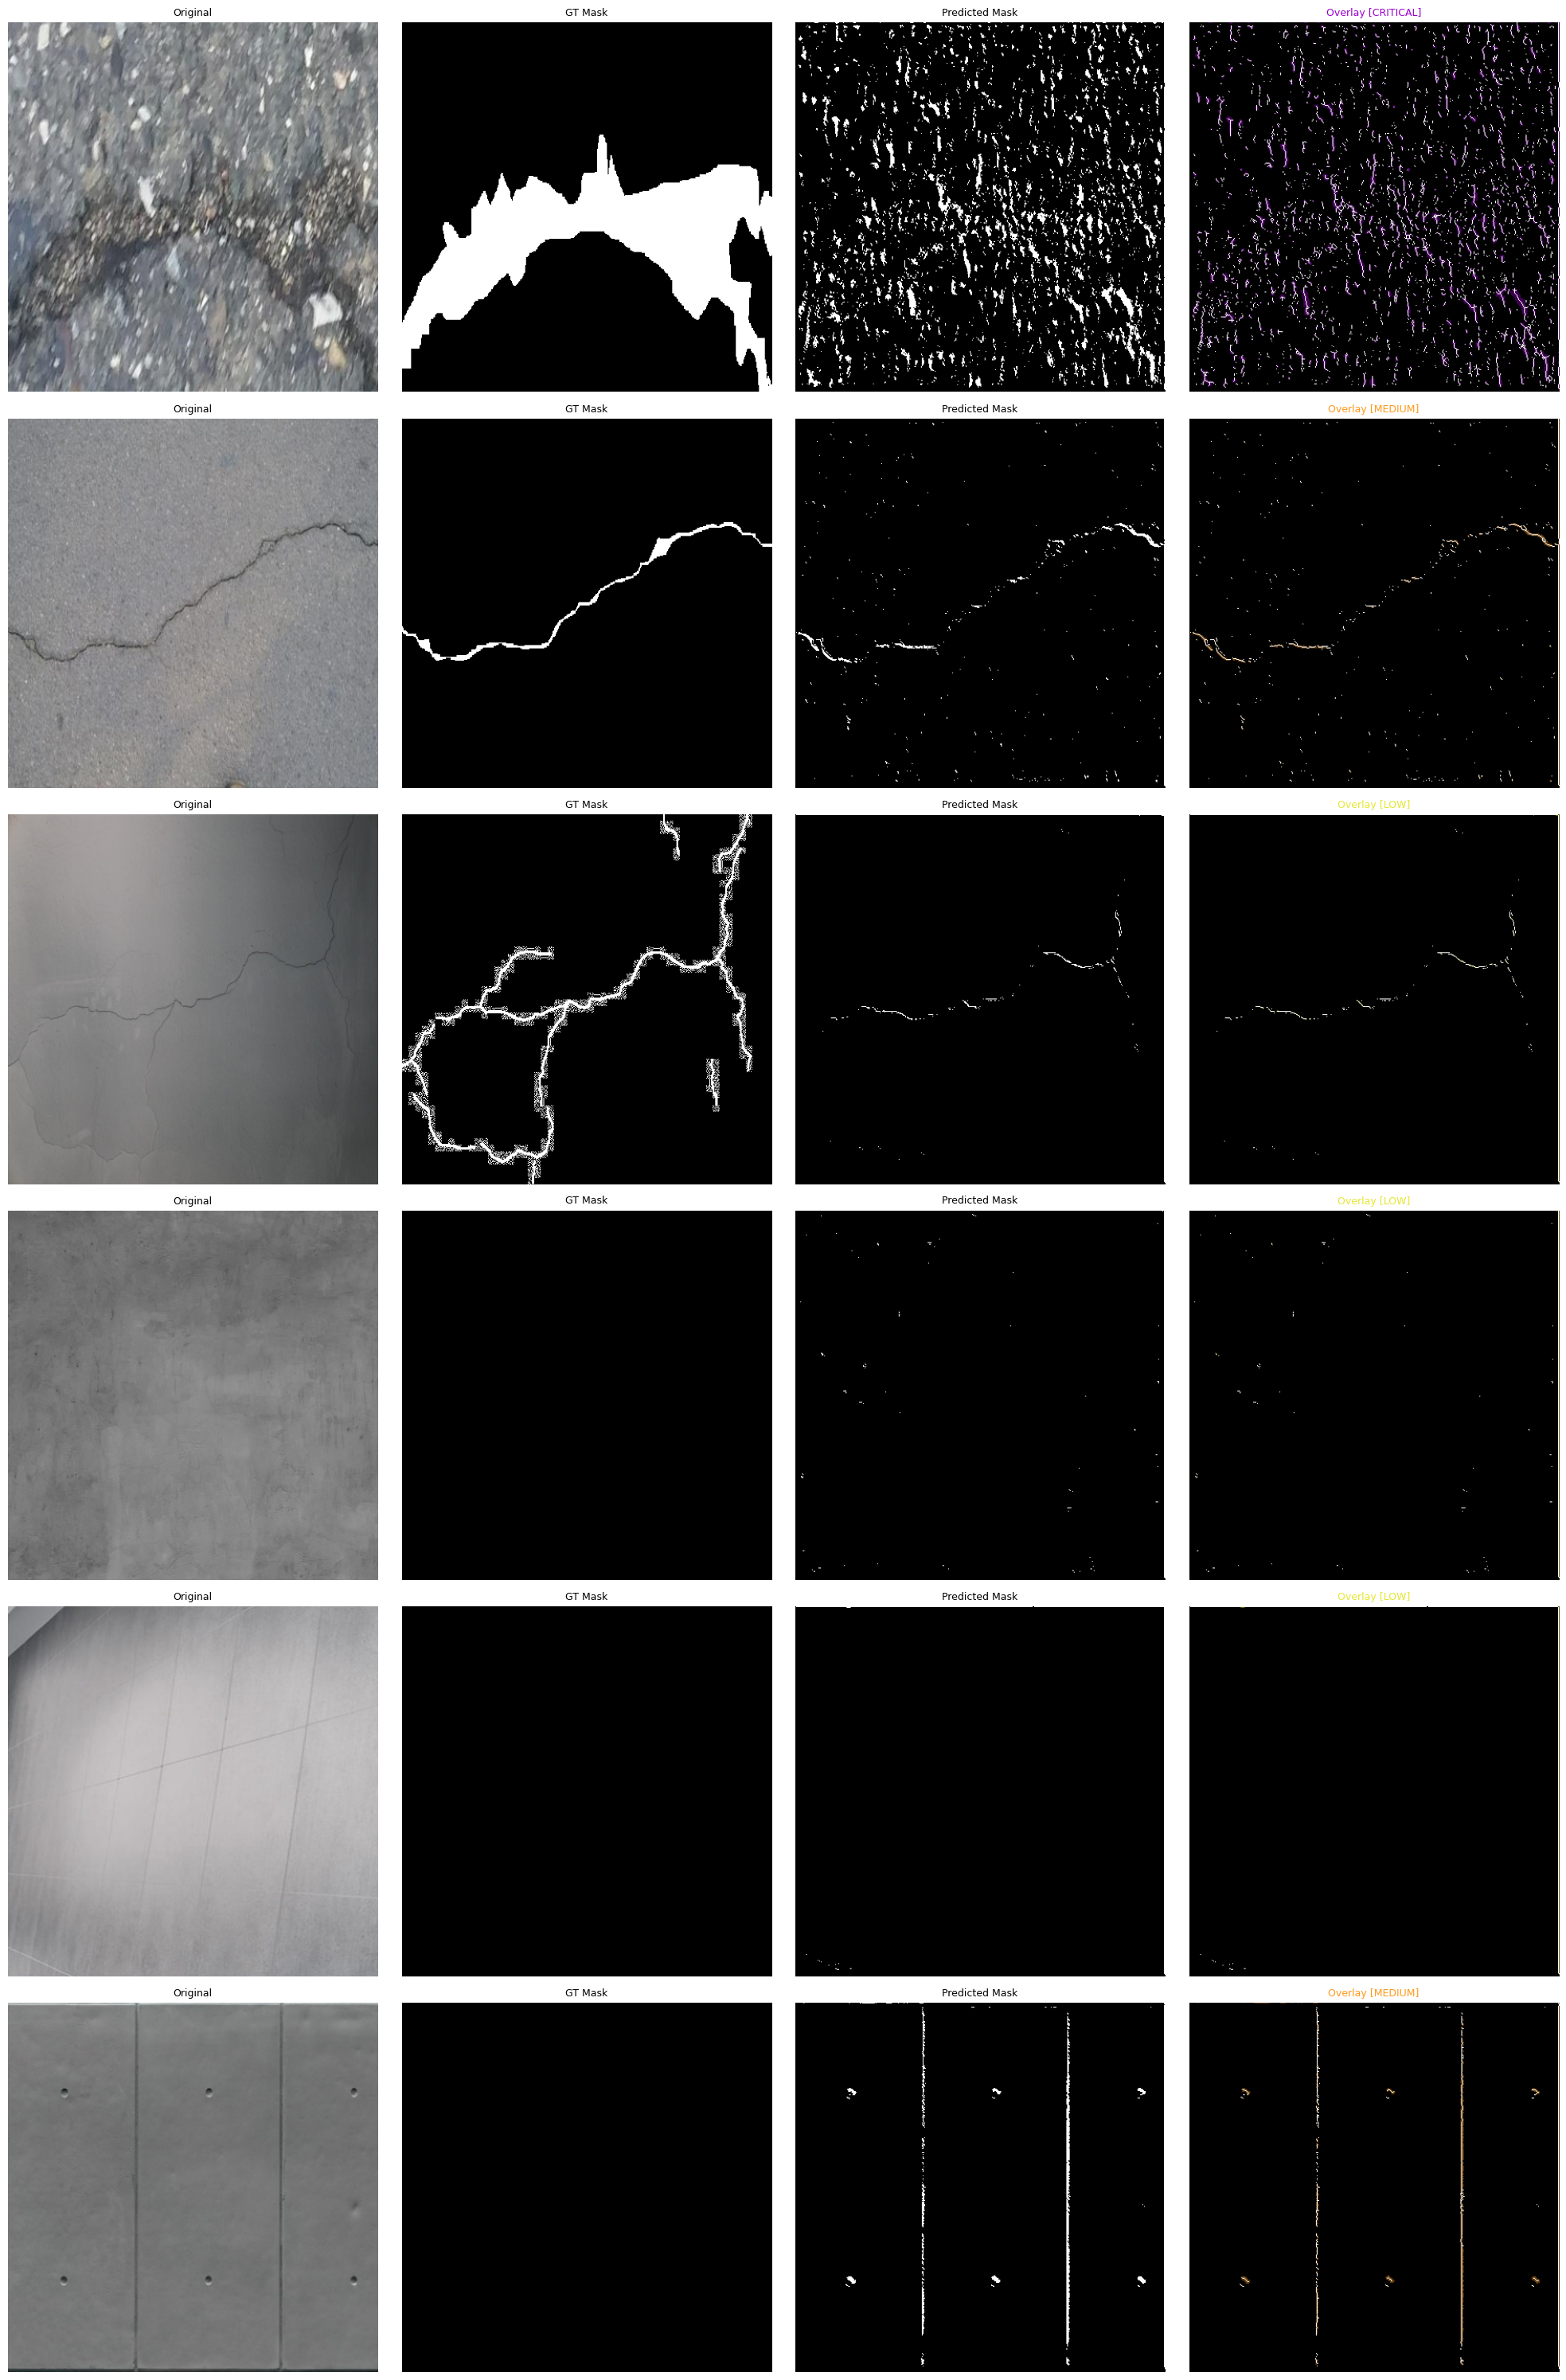

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import glob

# ==== CREATE MAIN OUTPUT FOLDER ====
OUTPUT_DIR = "File"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_test_imgs = sorted(
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.jpg")) +
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.png"))
)

# Pick samples
non_cracked = [p for p in all_test_imgs if "noncrack" in os.path.basename(p).lower()]
cracked     = [p for p in all_test_imgs if p not in non_cracked]

sample = random.sample(cracked, min(3, len(cracked))) + \
         random.sample(non_cracked, min(3, len(non_cracked)))
random.shuffle(sample)

print(f"Testing on {len(sample)} sample images...")

fig, axes = plt.subplots(len(sample), 4, figsize=(20, 5 * len(sample)))
if len(sample) == 1:
    axes = [axes]

for i, img_path in enumerate(sample):
    fname = os.path.basename(img_path)
    name = os.path.splitext(fname)[0]

    # ==== CREATE FOLDER FOR EACH SAMPLE ====
    sample_dir = os.path.join(OUTPUT_DIR, name)
    os.makedirs(sample_dir, exist_ok=True)

    # ==== LOAD GT ====
    gt_path = os.path.join(TEST_MASKS_DIR, fname)
    gt_mask = load_gt_mask(gt_path) if os.path.exists(gt_path) else None

    # ==== MODEL PREDICTION ====
    orig, prob, pred = predict_mask(img_path)
    m = compute_severity(pred)
    color = SEVERITY_COLOR[m["severity_level"]]

    # ==== SAVE ORIGINAL ====
    cv2.imwrite(os.path.join(sample_dir, "original.png"),
                cv2.cvtColor(orig, cv2.COLOR_RGB2BGR))

    # ==== SAVE GT ====
    if gt_mask is not None:
        cv2.imwrite(os.path.join(sample_dir, "gt.png"), gt_mask)

    # ==== SAVE PRED ====
    cv2.imwrite(os.path.join(sample_dir, "pred.png"), pred)

    # ==== CREATE OVERLAY ====
    overlay = orig.copy().astype(np.float32)

    mask = pred > 127

    # Ensure color is scaled correctly
    color_arr = np.array(color)
    if color_arr.max() <= 1:
        color_arr = color_arr * 255

    overlay[mask] = overlay[mask] * 0.6 + color_arr * 0.4

    # Skeleton overlay
    skel = m["skeleton"]
    overlay[skel] = [255, 255, 255]

    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # ==== SAVE OVERLAY ====
    cv2.imwrite(os.path.join(sample_dir, "overlay.png"),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    # ================= VISUALIZATION =================
    axes[i][0].imshow(orig)
    axes[i][0].set_title("Original", fontsize=9)
    axes[i][0].axis("off")

    if gt_mask is not None:
        axes[i][1].imshow(gt_mask, cmap="gray")
        axes[i][1].set_title("GT Mask", fontsize=9)
    else:
        axes[i][1].text(0.5, 0.5, "No GT", ha="center", va="center")
    axes[i][1].axis("off")

    axes[i][2].imshow(pred, cmap="gray")
    axes[i][2].set_title("Predicted Mask", fontsize=9)
    axes[i][2].axis("off")

    axes[i][3].imshow(overlay)
    axes[i][3].set_title(f"Overlay [{m['severity_level']}]", fontsize=9, color=color)
    axes[i][3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("File", 'zip', "File")
files.download("File.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 10 — Full Batch Severity Analysis on Test Set

Runs on all images in `test/images/`.  
Saves `crack_severity_results.csv` with one row per image.

> **Tip:** Set `MAX_IMAGES` to a small number (e.g. 50) for a quick trial run.

In [ ]:
OUTPUT_CSV = "/content/crack_severity_results.csv"
OUTPUT_VIS = "/content/crack_severity_vis"
os.makedirs(OUTPUT_VIS, exist_ok=True)

MAX_IMAGES  = None   # ✏️ set to e.g. 100 for a quick run; None = all images
SAVE_VISUALS = True  # set False to skip saving overlay images (faster)

# ── Collect all test images ───────────────────────────────────────────────────
image_paths = sorted(
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.jpg")) +
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.jpeg")) +
    glob.glob(os.path.join(TEST_IMGS_DIR, "*.png"))
)
if MAX_IMAGES:
    image_paths = image_paths[:MAX_IMAGES]

print(f"Processing {len(image_paths)} test images...")

# ── CSV header ────────────────────────────────────────────────────────────────
FIELDS = [
    "filename", "is_noncracked_gt",
    "severity_level", "crack_area_pct",
    "max_width_px", "mean_width_px",
    "crack_length_px", "num_crack_regions",
    "iou", "dice",
]

results = []

for img_path in tqdm(image_paths, desc="Severity Analysis"):
    fname = os.path.basename(img_path)
    stem  = os.path.splitext(fname)[0]
    is_noncracked = "noncrack" in fname.lower()

    try:
        orig, prob, pred = predict_mask(img_path)
        m = compute_severity(pred)

        # IoU / Dice against GT mask (same filename in masks folder)
        gt_path = os.path.join(TEST_MASKS_DIR, fname)
        iou = dice = None
        if os.path.exists(gt_path):
            gt_mask = load_gt_mask(gt_path)
            if gt_mask is not None:
                iou, dice = seg_metrics(pred, gt_mask)

        row = {
            "filename":           fname,
            "is_noncracked_gt":   is_noncracked,
            "severity_level":     m["severity_level"],
            "crack_area_pct":     m["crack_area_pct"],
            "max_width_px":       m["max_width_px"],
            "mean_width_px":      m["mean_width_px"],
            "crack_length_px":    m["crack_length_px"],
            "num_crack_regions":  m["num_crack_regions"],
            "iou":                iou,
            "dice":               dice,
        }
        results.append(row)

        # ── Save overlay visual ───────────────────────────────────────────────
        if SAVE_VISUALS:
            color = SEVERITY_COLOR[m["severity_level"]]
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(orig); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(pred, cmap="gray")
            axes[1].set_title(f"Predicted Mask")
            axes[1].axis("off")
            axes[2].imshow(orig)
            ov = np.zeros((*pred.shape, 4), dtype=np.float32)
            ov[pred > 127] = [*color, 0.5]
            axes[2].imshow(ov)
            sk = np.zeros((*m["skeleton"].shape, 4), dtype=np.float32)
            sk[m["skeleton"]] = [1, 1, 1, 0.9]
            axes[2].imshow(sk)
            sev_str = (f"{m['severity_level']}  |  "
                       f"Area {m['crack_area_pct']:.2f}%  |  "
                       f"MaxW {m['max_width_px']:.1f}px")
            if iou is not None:
                sev_str += f"  |  IoU {iou:.3f}"
            axes[2].set_title(sev_str, color=color, fontweight="bold")
            axes[2].axis("off")
            plt.tight_layout()
            out_vis = os.path.join(OUTPUT_VIS, stem + "_sev.png")
            plt.savefig(out_vis, dpi=80, bbox_inches="tight")
            plt.close()

    except Exception as e:
        print(f"⚠️  Skipped {fname}: {e}")

# ── Write CSV ─────────────────────────────────────────────────────────────────
with open(OUTPUT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDS)
    writer.writeheader()
    writer.writerows(results)

print(f"\n✅ Done. {len(results)} images processed.")
print(f"   CSV  → {OUTPUT_CSV}")
print(f"   Visuals → {OUTPUT_VIS}")

NameError: name 'os' is not defined

## Cell 11 — Summary Statistics

In [ ]:
df = pd.read_csv(OUTPUT_CSV)

print("=" * 55)
print("OVERALL SUMMARY")
print("=" * 55)
print(f"Total images processed : {len(df)}")
print(f"  Non-cracked (GT)     : {df['is_noncracked_gt'].sum()}")
print(f"  Cracked (GT)         : {(~df['is_noncracked_gt']).sum()}")
print()

print("SEVERITY DISTRIBUTION")
order = ["NONE", "LOW", "MEDIUM", "HIGH", "CRITICAL"]
vc    = df["severity_level"].value_counts()
for lvl in order:
    n   = vc.get(lvl, 0)
    pct = n / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {lvl:<10} {n:>5}  ({pct:5.1f}%)  {bar}")
print()

# Segmentation metrics (only where GT mask exists)
df_gt = df.dropna(subset=["iou", "dice"])
if len(df_gt) > 0:
    print("SEGMENTATION METRICS (vs GT masks)")
    print(f"  Mean IoU  : {df_gt['iou'].mean():.4f}")
    print(f"  Mean Dice : {df_gt['dice'].mean():.4f}")
    print(f"  Images with GT : {len(df_gt)} / {len(df)}")
    print()

# Crack area stats (cracked only)
cracked_df = df[df["crack_area_pct"] > 0]
if len(cracked_df) > 0:
    print("CRACK METRICS (cracked images only)")
    print(cracked_df[["crack_area_pct", "max_width_px", "crack_length_px"]].describe().round(2))

## Cell 12 — Plots

In [ ]:
df = pd.read_csv(OUTPUT_CSV)
order  = ["NONE", "LOW", "MEDIUM", "HIGH", "CRITICAL"]
vc     = df["severity_level"].value_counts()
labels = [k for k in order if k in vc]
vals   = [vc[k] for k in labels]
colors = [SEVERITY_COLOR[k] for k in labels]

df_gt      = df.dropna(subset=["iou", "dice"])
cracked_df = df[df["crack_area_pct"] > 0]

n_plots = 2 + (1 if len(df_gt) > 0 else 0) + (1 if len(cracked_df) > 0 else 0)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
ax_idx = 0

# Plot 1 — Severity bar chart
axes[ax_idx].bar(labels, vals, color=colors, edgecolor="black")
axes[ax_idx].set_title("Severity Distribution", fontsize=13)
axes[ax_idx].set_xlabel("Level"); axes[ax_idx].set_ylabel("Count")
for i, v in enumerate(vals):
    axes[ax_idx].text(i, v + 0.3, str(v), ha="center", fontweight="bold")
ax_idx += 1

# Plot 2 — Crack area histogram
axes[ax_idx].hist(cracked_df["crack_area_pct"] if len(cracked_df) > 0 else [],
                  bins=30, color="steelblue", edgecolor="black")
axes[ax_idx].set_title("Crack Area % (cracked only)", fontsize=13)
axes[ax_idx].set_xlabel("Crack Area (%)"); axes[ax_idx].set_ylabel("Count")
ax_idx += 1

# Plot 3 — IoU distribution
if len(df_gt) > 0:
    axes[ax_idx].hist(df_gt["iou"], bins=30, color="mediumseagreen", edgecolor="black")
    axes[ax_idx].axvline(df_gt["iou"].mean(), color="red", linestyle="--",
                         label=f"Mean IoU = {df_gt['iou'].mean():.3f}")
    axes[ax_idx].set_title("IoU Distribution", fontsize=13)
    axes[ax_idx].set_xlabel("IoU"); axes[ax_idx].set_ylabel("Count")
    axes[ax_idx].legend()
    ax_idx += 1

# Plot 4 — Max crack width distribution
if len(cracked_df) > 0:
    axes[ax_idx].hist(cracked_df["max_width_px"], bins=30, color="salmon", edgecolor="black")
    axes[ax_idx].set_title("Max Crack Width (cracked only)", fontsize=13)
    axes[ax_idx].set_xlabel("Max Width (px)"); axes[ax_idx].set_ylabel("Count")

plt.tight_layout()
plt.savefig("/content/severity_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved to /content/severity_dashboard.png")

## Cell 13 — Download Results

In [ ]:
from google.colab import files

files.download(OUTPUT_CSV)
files.download("/content/severity_dashboard.png")
print("✅ Downloads triggered.")

---
## 📌 Tuning Guide

### Prediction threshold (`PRED_THRESHOLD` in Cell 8)
| Value | Effect |
|-------|--------|
| 0.3   | More sensitive — catches hairline cracks, more FP |
| 0.5   | Default balanced point |
| 0.7   | Conservative — only high-confidence cracks |

### Severity thresholds (`SEVERITY_THRESHOLDS` in Cell 8)
Based on **crack area %**. Adjust to match your structural standard (e.g. IS 456, ACI 318).

### Real-world width conversion
If you know the physical coverage per pixel:
```python
mm_per_px = physical_width_mm / IMG_SIZE
max_width_mm = row['max_width_px'] * mm_per_px
```

### Weight loading errors
If `load_weights` raises a shape mismatch, try:
```python
model.load_weights(MODEL_H5_PATH, by_name=False, skip_mismatch=True)
```
Then check which layers were skipped — it usually points to a filter count mismatch.

In [ ]:
import os

target_name = "Rissbilder_for_Florian_9S6A3112_1349_1614_2446_2337"

found_paths = []

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if target_name in f:
            found_paths.append(os.path.join(root, f))

print("Found files:")
for p in found_paths:
    print(p)

In [ ]:
from google.colab import files

# Image path
img_path = "/kaggle/input/crack-segmentation-dataset/test/images/Volker_DSC01677_26_956_1697_1698.jpg"

# Mask path
mask_path = "/kaggle/input/crack-segmentation-dataset/test/masks/Rissbilder_for_Florian_9S6A3112_1349_1614_2446_2337.jpg"

files.download(img_path)
files.download(mask_path)